# MNIST Handwritten Digit Recognition
### Training a Convolutional Neural Network (CNN) in PyTorch

This notebook demonstrates how to load the MNIST dataset, preprocess the images, build a Convolutional Neural Network (CNN) model, train the model, and evaluate its performance. The trained model weights will be saved and used in our interactive Streamlit application.

## 1. Imports and Setup

In [18]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F

# Set random seed for reproducibility
torch.manual_seed(42)

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


## 2. Load and Preprocess MNIST Dataset

The MNIST dataset consists of 60,000 training images and 10,000 testing images of handwritten digits (0-9). Each image is 28x28 pixels in grayscale.

We apply the following preprocessing:
- Convert images to PyTorch Tensors.
- Normalize pixels using the standard MNIST mean `0.1307` and standard deviation `0.3081`.

In [19]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

# Download and prepare datasets
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

Training set size: 60000
Test set size: 10000


## 3. Visualize Sample Data

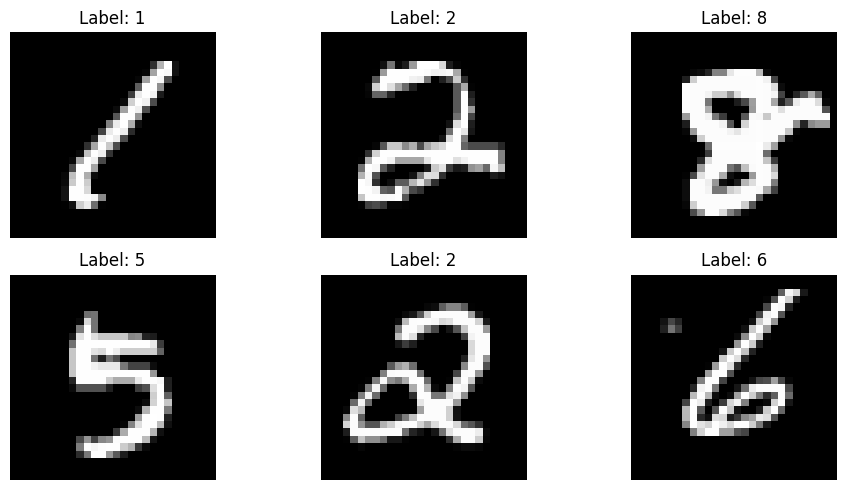

In [20]:
# Load a batch of training data
data_iter = iter(train_loader)
images, labels = next(data_iter)

# Unnormalize helper function
def imshow(img, title):
    img = img * 0.3081 + 0.1307 # Denormalize
    npimg = img.numpy()
    plt.imshow(npimg, cmap='gray')
    plt.title(title)
    plt.axis('off')

# Plot the first 6 images
plt.figure(figsize=(10, 5))
for i in range(6):
    plt.subplot(2, 3, i + 1)
    imshow(images[i].squeeze(), f"Label: {labels[i].item()}")
plt.tight_layout()
plt.show()

In [26]:
print("Hi")
class MNISTCNN(nn.Module):
    """
    A standard Convolutional Neural Network (CNN) for MNIST Digit Recognition.
    Includes helper methods to extract intermediate activations for visualization.
    """
    def __init__(self):
        super(MNISTCNN, self).__init__()
        # Conv Layer 1: 1 input channel (grayscale), 32 output channels, kernel size 3
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        # Conv Layer 2: 32 input channels, 64 output channels, kernel size 3
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        
        # Max pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Dropout to prevent overfitting
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        
        # Fully connected layers
        # MNIST input size is 28x28
        # conv1 -> 32 x 28 x 28 -> pool -> 32 x 14 x 14
        # conv2 -> 64 x 14 x 14 -> pool -> 64 x 7 x 7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Convolutional layers with pooling and activations
        x = F.relu(self.conv1(x))
        x = self.pool(x)
        x = F.relu(self.conv2(x))
        x = self.pool(x)
        x = self.dropout1(x)
        
        # Flatten for fully connected layers
        x = torch.flatten(x, 1)
        x = F.relu(self.fc1(x))
        x = self.dropout2(x)
        x = self.fc2(x)
        
        return x

    def get_activations(self, x):
        """
        Extract activations of conv1 and conv2 layers for visualization in Streamlit.
        
        Args:
            x (torch.Tensor): Preprocessed input tensor of shape (1, 1, 28, 28)
            
        Returns:
            tuple: (conv1_activations, conv2_activations)
        """
        # Ensure model is in eval mode
        self.eval()
        with torch.no_grad():
            act1 = F.relu(self.conv1(x))
            pooled1 = self.pool(act1)
            act2 = F.relu(self.conv2(pooled1))
        return act1, act2

model = MNISTCNN().to(device)
print(model)

Hi
MNISTCNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (dropout2): Dropout(p=0.5, inplace=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


## 5. Train the Model

We use **Cross-Entropy Loss** and the **Adam Optimizer** to update model parameters.

Using device: cuda
Starting training...
==> Epoch 1 summary | Train Loss: 0.2389, Train Acc: 92.64% | Test Loss: 0.0539, Test Acc: 98.20%
Validation loss decreased. Saved best model checkpoint to mnist_cnn.pth
==> Epoch 2 summary | Train Loss: 0.0858, Train Acc: 97.48% | Test Loss: 0.0348, Test Acc: 98.86%
Validation loss decreased. Saved best model checkpoint to mnist_cnn.pth
==> Epoch 3 summary | Train Loss: 0.0671, Train Acc: 98.00% | Test Loss: 0.0312, Test Acc: 98.94%
Validation loss decreased. Saved best model checkpoint to mnist_cnn.pth
==> Epoch 4 summary | Train Loss: 0.0566, Train Acc: 98.34% | Test Loss: 0.0253, Test Acc: 99.10%
Validation loss decreased. Saved best model checkpoint to mnist_cnn.pth
==> Epoch 5 summary | Train Loss: 0.0485, Train Acc: 98.53% | Test Loss: 0.0241, Test Acc: 99.12%
Validation loss decreased. Saved best model checkpoint to mnist_cnn.pth
==> Epoch 6 summary | Train Loss: 0.0440, Train Acc: 98.61% | Test Loss: 0.0228, Test Acc: 99.25%
Validation l

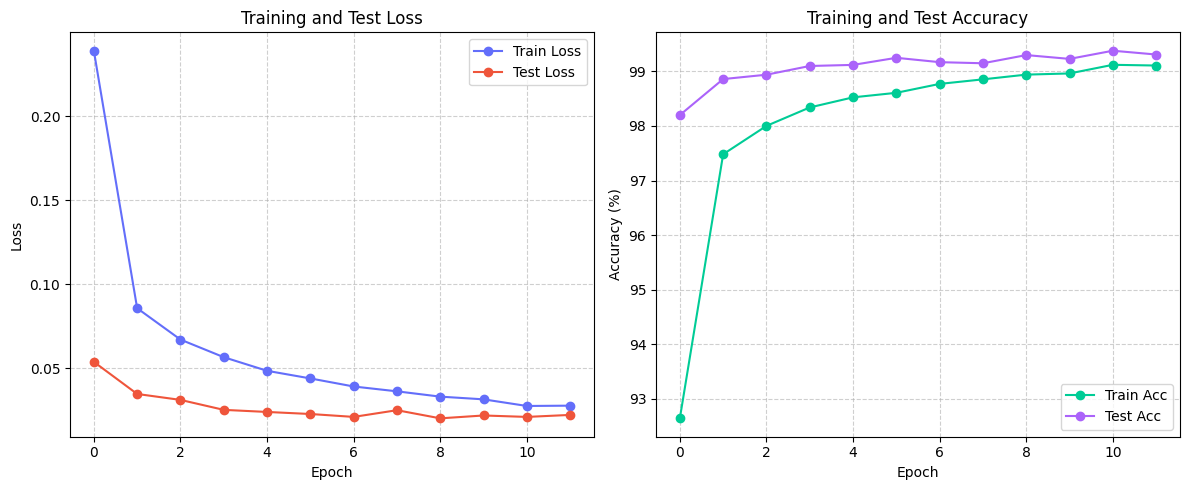

In [28]:
def train_model(epochs=15, batch_size=128, learning_rate=0.001, patience=3):
    # Set device
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Using device: {device}")
    
    # 1. Define image preprocessing/transforms
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,)) # MNIST standard normalization constants
    ])
    
    # 2. Download and load datasets
    print("Downloading and preparing datasets...")
    train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
    test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    
    train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)
    
    # 3. Instantiate model, loss, and optimizer
    model = MNISTCNN().to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    
    # 4. Training Loop
    history = {
        'train_loss': [],
        'train_acc': [],
        'test_loss': [],
        'test_acc': []
    }
    
    best_loss = float('inf')
    patience_counter = 0
    model_path = 'mnist_cnn.pth'
    
    print("Starting training...")
    for epoch in range(1, epochs + 1):
        # Training Phase
        model.train()
        running_loss = 0.0
        correct = 0
        total = 0
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)
            
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * data.size(0)
            _, predicted = torch.max(output.data, 1)
            total += target.size(0)
            correct += (predicted == target).sum().item()
                
        epoch_train_loss = running_loss / len(train_loader.dataset)
        epoch_train_acc = 100. * correct / total
        
        # Evaluation Phase
        model.eval()
        test_loss = 0.0
        test_correct = 0
        test_total = 0
        
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                
                test_loss += loss.item() * data.size(0)
                _, predicted = torch.max(output.data, 1)
                test_total += target.size(0)
                test_correct += (predicted == target).sum().item()
                
        epoch_test_loss = test_loss / len(test_loader.dataset)
        epoch_test_acc = 100. * test_correct / test_total
        
        # Save history
        history['train_loss'].append(epoch_train_loss)
        history['train_acc'].append(epoch_train_acc)
        history['test_loss'].append(epoch_test_loss)
        history['test_acc'].append(epoch_test_acc)
        
        print(f"==> Epoch {epoch} summary | Train Loss: {epoch_train_loss:.4f}, Train Acc: {epoch_train_acc:.2f}% | Test Loss: {epoch_test_loss:.4f}, Test Acc: {epoch_test_acc:.2f}%")
        
        # Early stopping logic & best model saving
        if epoch_test_loss < best_loss:
            best_loss = epoch_test_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print(f"Validation loss decreased. Saved best model checkpoint to {model_path}")
        else:
            pvariance_val = epoch_test_loss - best_loss
            patience_counter += 1
            print(f"Validation loss did not decrease (diff: +{pvariance_val:.4f}). Early stopping counter: {patience_counter} of {patience}")
            
        if patience_counter >= patience:
            print("Early stopping triggered! Training halted.")
            break
            
    # 5. Plot & save training history
    plt.figure(figsize=(12, 5))
    
    # Plot loss
    plt.subplot(1, 2, 1)
    plt.plot(history['train_loss'], label='Train Loss', color='#636EFA', marker='o')
    plt.plot(history['test_loss'], label='Test Loss', color='#EF553B', marker='o')
    plt.title('Training and Test Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    # Plot accuracy
    plt.subplot(1, 2, 2)
    plt.plot(history['train_acc'], label='Train Acc', color='#00CC96', marker='o')
    plt.plot(history['test_acc'], label='Test Acc', color='#AB63FA', marker='o')
    plt.title('Training and Test Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()
    
    plt.tight_layout()
    plt.savefig('training_history.png', dpi=300)
    print("Training history plot saved as training_history.png")
    
    return history

# Train the model for 3 epochs (achieves >98% accuracy quickly)
history = train_model(epochs=15, batch_size=128, learning_rate=0.001)

## 6. Evaluate Model on Sample Predictions

Let's visualize predictions made on the test dataset.

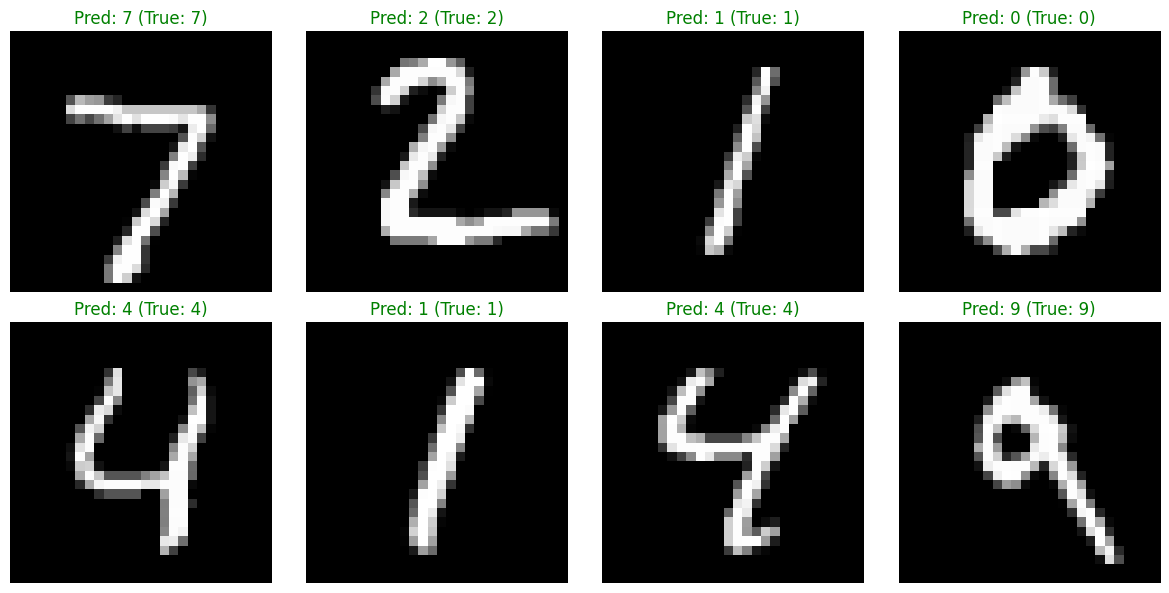

In [33]:
model.load_state_dict(torch.load('mnist_cnn.pth', map_location=device))
model.eval()
test_iter = iter(test_loader)
test_images, test_labels = next(test_iter)

with torch.no_grad():
    outputs = model(test_images.to(device))
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    # Green title for correct, red for incorrect
    is_correct = predicted[i].item() == test_labels[i].item()
    color = 'green' if is_correct else 'red'
    imshow(test_images[i].squeeze(), f"Pred: {predicted[i].item()} (True: {test_labels[i].item()})")
    plt.title(f"Pred: {predicted[i].item()} (True: {test_labels[i].item()})", color=color)
plt.tight_layout()
plt.show()

In [34]:
torch.save(model.load_state_dict(torch.load('mnist_cnn.pth', map_location=device)), "mnist_cnn.pth")